# Unified three-method comparison: xG vs xT vs VAEP (cross-gender transfer)

One clean run so the three methods are **strictly comparable**: identical women test
set (same game-level split), identical men training data (2015/16 top-5 leagues),
goalkeepers excluded from all, comparable player filter. Output = one table of
Spearman(men-model ranking vs women-model ranking) per method, plus the by-position
breakdown for VAEP.

**Interpretation:** if xG and xT are ~0.97 (look unbiased) but VAEP is clearly lower,
the finding is that cross-gender bias is real but only a fine-grained action-value model
(VAEP) can detect it. Men control is 2015/16 vs women 2023/24 (era gap — a stated
limitation; no complete recent men's open league season exists).

Self-contained; runs top-to-bottom on Colab. Men data step is slow; cached.

## 0. Install (note multimethod pin)

In [1]:
!pip install socceraction statsbombpy "multimethod<2" scikit-learn xgboost scipy pandas numpy matplotlib -q


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, numpy as np, pandas as pd
from socceraction.data.statsbomb import StatsBombLoader
import socceraction.spadl as spadl
import socceraction.vaep.features as fs
import socceraction.vaep.labels as lab
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy import stats
import matplotlib.pyplot as plt
os.makedirs('data', exist_ok=True)
SBL = StatsBombLoader(getter='remote', creds={})
print('ready')

ready


## 1. Load SPADL actions + positions (cached)

Women 2023/24 top-5, Men 2015/16 top-4 complete leagues.

In [5]:
WOMEN=[(37,281,"WSL"),(135,281,"Frauen Bundesliga"),(182,281,"Liga F"),(131,281,"Serie A Women"),(49,107,"NWSL")]
MEN=[(11,27,"La Liga"),(2,27,"Premier League"),(12,27,"Serie A"),(7,27,"Ligue 1")]

def load_spadl(comps, tag):
    ca=f'vaep_data/{tag}_spadl.parquet'; cp=f'vaep_data/{tag}_pos.parquet'
    if os.path.exists(ca) and os.path.exists(cp):
        print(f'[cache] {tag}'); return pd.read_parquet(ca), pd.read_parquet(cp)
    A=[]; POS=[]
    for cid,sid,label in comps:
        try: games=SBL.games(competition_id=cid,season_id=sid)
        except Exception as e: print('  !',label,e); continue
        print(f'[load] {label}: {len(games)} games')
        for _,g in games.iterrows():
            try:
                ev=SBL.events(g.game_id)
                a=spadl.statsbomb.convert_to_actions(ev,home_team_id=g.home_team_id)
                a['league']=label; A.append(a)
                if 'position_name' in ev.columns:
                    POS.append(ev[['player_id','position_name']].dropna())
            except Exception: continue
    act=pd.concat(A,ignore_index=True)
    pos=pd.concat(POS,ignore_index=True) if POS else pd.DataFrame(columns=['player_id','position_name'])
    act.to_parquet(ca,index=False); pos.to_parquet(cp,index=False)
    print(f'[cache] wrote {tag}: {len(act):,} actions'); return act,pos

print('=== women ==='); w_act,w_pos = load_spadl(WOMEN,'women')
print('=== men (slow) ==='); m_act,_ = load_spadl(MEN,'men2015')
w_act=spadl.add_names(w_act); m_act=spadl.add_names(m_act)
print('women',len(w_act),'men',len(m_act))

=== women ===
[cache] women
=== men (slow) ===
[cache] men2015
women 1506844 men 3043560


## 2. ONE shared setup: women game-level split, GK map, player filter

Every method below uses THIS split and THIS goalkeeper exclusion, so the three
Spearman values are strictly comparable.

In [6]:
rng=np.random.default_rng(42)
wgames=w_act['game_id'].unique()
TEST_GAMES=set(rng.choice(wgames,size=int(len(wgames)*0.30),replace=False))
print('women test games:',len(TEST_GAMES),'of',len(wgames))

posmap=(w_pos.groupby('player_id')['position_name']
        .agg(lambda s:s.value_counts().index[0]).to_dict()) if len(w_pos) else {}
def is_gk(pid): return 'Goalkeeper' in str(posmap.get(pid,''))
print('positions mapped:',len(posmap),'| GKs:',sum('Goalkeeper' in str(v) for v in posmap.values()))

MIN_SHOTS=10       # xG player filter
MIN_ACTIONS=100    # xT/VAEP player filter

women test games: 231 of 771
positions mapped: 1533 | GKs: 138


## 3. Method 1 — xG

In [7]:
def shots_tbl(a):
    s=a[a['type_name']=='shot'].copy()
    s['goal']=(s['result_name']=='success').astype(int)
    dx=105-s['start_x']; dy=34-s['start_y']
    s['distance']=np.hypot(dx,dy)
    s['angle']=np.arctan2(7.32*dx, dx**2+dy**2-(7.32/2)**2).abs()
    return s[['game_id','player_id','league','distance','angle','goal']]

wsh=shots_tbl(w_act); msh=shots_tbl(m_act)
wsh_te=wsh[wsh.game_id.isin(TEST_GAMES)]; wsh_tr=wsh[~wsh.game_id.isin(TEST_GAMES)]
F=['distance','angle']
mxg=XGBClassifier(n_estimators=200,max_depth=3,learning_rate=0.05,random_state=42).fit(msh[F],msh['goal'])
wxg=XGBClassifier(n_estimators=200,max_depth=3,learning_rate=0.05,random_state=42).fit(wsh_tr[F],wsh_tr['goal'])
d=wsh_te.copy(); d['m']=mxg.predict_proba(d[F])[:,1]; d['w']=wxg.predict_proba(d[F])[:,1]
pxg=d.groupby('player_id').agg(m=('m','sum'),w=('w','sum'),n=('m','size')).reset_index()
pxg=pxg[(pxg.n>=MIN_SHOTS)&(~pxg.player_id.map(is_gk))]
rho_xg=stats.spearmanr(pxg.m,pxg.w)[0]
print(f'xG  | players={len(pxg)}  Spearman={rho_xg:.3f}')

xG  | players=178  Spearman=0.977


## 4. Method 2 — position-based xT (same split)

In [8]:
M,N=12,16
def cellf(x,y): return min(int(y/68*M),M-1),min(int(x/105*N),N-1)
def train_xt(a,n_iter=30):
    sh=a[a.type_name=='shot']; mv=a[a.type_name.isin(['pass','dribble'])]
    sc=np.zeros((M,N));gc=np.zeros((M,N));mc=np.zeros((M,N));T=np.zeros((M,N,M,N))
    for _,s in sh.iterrows():
        cy,cx=cellf(s.start_x,s.start_y);sc[cy,cx]+=1;gc[cy,cx]+=(s.result_name=='success')
    for _,m in mv.iterrows():
        cy,cx=cellf(m.start_x,m.start_y);mc[cy,cx]+=1
        ty,tx=cellf(m.end_x,m.end_y);T[cy,cx,ty,tx]+=1
    tot=sc+mc;tot[tot==0]=1;sp=sc/tot;mp=mc/tot
    gp=np.divide(gc,sc,out=np.zeros_like(gc),where=sc>0)
    Ts=T.sum(axis=(2,3),keepdims=True);Ts[Ts==0]=1;T=T/Ts
    xT=np.zeros((M,N))
    for _ in range(n_iter): xT=sp*gp+mp*np.einsum('ijkl,kl->ij',T,xT)
    return xT
xT_m=train_xt(m_act); xT_w=train_xt(w_act[~w_act.game_id.isin(TEST_GAMES)])
wte=w_act[w_act.game_id.isin(TEST_GAMES)]
mv=wte[wte.type_name.isin(['pass','dribble'])].copy()
def val(a,xt):
    out=np.empty(len(a))
    for i,r in enumerate(a.itertuples(index=False)):
        sy,sx=cellf(r.start_x,r.start_y);ey,ex=cellf(r.end_x,r.end_y);out[i]=xt[ey,ex]-xt[sy,sx]
    return out
mv['m']=val(mv,xT_m);mv['w']=val(mv,xT_w)
pxt=mv.groupby('player_id').agg(m=('m','sum'),w=('w','sum'),n=('m','size')).reset_index()
pxt=pxt[(pxt.n>=MIN_ACTIONS)&(~pxt.player_id.map(is_gk))]
rho_xt=stats.spearmanr(pxt.m,pxt.w)[0]
print(f'xT  | players={len(pxt)}  Spearman={rho_xt:.3f}')

xT  | players=902  Spearman=0.991


## 5. Method 3 — VAEP (same split)

In [9]:
XFNS=[fs.actiontype_onehot,fs.result_onehot,fs.bodypart_onehot,fs.startlocation,
      fs.endlocation,fs.movement,fs.space_delta,fs.startpolar,fs.endpolar,fs.team,fs.time_delta]
def make_xy(actions):
    Xs,ys,meta=[],[],[]
    for gid,ga in actions.groupby('game_id'):
        ga=ga.reset_index(drop=True); gs=fs.gamestates(ga,3)
        Xi=pd.concat([fn(gs) for fn in XFNS],axis=1)
        yi=pd.concat([lab.scores(ga,3),lab.concedes(ga,3)],axis=1)
        cur=ga.iloc[:len(Xi)].reset_index(drop=True)
        mi=pd.DataFrame({'game_id':gid,'player_id':cur['player_id'].values,
                         'type_name':cur['type_name'].values,
                         'start_x':cur['start_x'].values})
        Xs.append(Xi);ys.append(yi);meta.append(mi)
    return (pd.concat(Xs).reset_index(drop=True).fillna(0),
            pd.concat(ys).reset_index(drop=True).fillna(0),
            pd.concat(meta).reset_index(drop=True))
print('women X/y...'); Xw,yw,mw=make_xy(w_act)
print('men X/y...');   Xm,ym,mm=make_xy(m_act)
def train_v(X,y):
    s=HistGradientBoostingClassifier(max_iter=300,learning_rate=0.05,random_state=42).fit(X,y['scores'])
    c=HistGradientBoostingClassifier(max_iter=300,learning_rate=0.05,random_state=42).fit(X,y['concedes'])
    return s,c
mask_te=mw['game_id'].isin(TEST_GAMES).values
ms_,mc_=train_v(Xm,ym); ws_,wc_=train_v(Xw[~mask_te],yw[~mask_te])
def vv(s,c,X): return s.predict_proba(X)[:,1]-c.predict_proba(X)[:,1]
mt=mw[mask_te].reset_index(drop=True).copy()
mt['m']=vv(ms_,mc_,Xw[mask_te].reset_index(drop=True))
mt['w']=vv(ws_,wc_,Xw[mask_te].reset_index(drop=True))
mt['bias']=mt['m']-mt['w']
pv=mt.groupby('player_id').agg(m=('m','sum'),w=('w','sum'),n=('m','size')).reset_index()
pv=pv[(pv.n>=MIN_ACTIONS)&(~pv.player_id.map(is_gk))]
rho_v=stats.spearmanr(pv.m,pv.w)[0]
print(f'VAEP| players={len(pv)}  Spearman={rho_v:.3f}')

women X/y...
men X/y...
VAEP| players=956  Spearman=0.853


## 6. The comparison table (strictly comparable)

             method  players  Spearman_men_vs_women
  xG (shot quality)      178                  0.977
xT (position-based)      902                  0.991
VAEP (action value)      956                  0.853

Lower Spearman = men-trained model ranks women players more differently
from the women-trained model = larger cross-gender transfer bias.


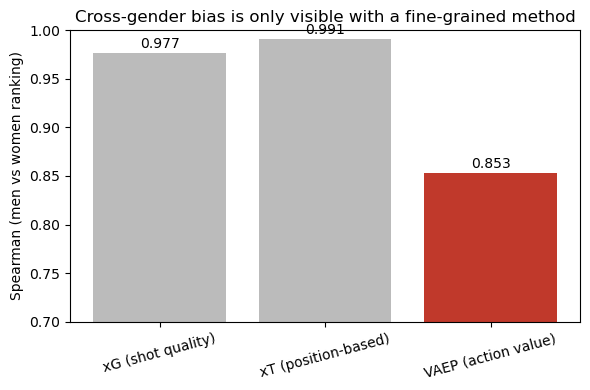

In [10]:
comp=pd.DataFrame({
    'method':['xG (shot quality)','xT (position-based)','VAEP (action value)'],
    'players':[len(pxg),len(pxt),len(pv)],
    'Spearman_men_vs_women':[round(rho_xg,3),round(rho_xt,3),round(rho_v,3)],
})
print(comp.to_string(index=False))
print('\nLower Spearman = men-trained model ranks women players more differently')
print('from the women-trained model = larger cross-gender transfer bias.')

fig,ax=plt.subplots(figsize=(6,4))
ax.bar(comp['method'], comp['Spearman_men_vs_women'], color=['#bbb','#bbb','#c0392b'])
ax.set_ylim(0.7,1.0); ax.set_ylabel('Spearman (men vs women ranking)')
ax.set_title('Cross-gender bias is only visible with a fine-grained method')
for i,v in enumerate(comp['Spearman_men_vs_women']): ax.text(i,v+0.005,f'{v:.3f}',ha='center')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 7. VAEP by position + by action type (mechanism)

In [11]:
# by position
pv2=pv.copy()
pv2['position']=pv2['player_id'].map(posmap)
pv2['rank_m']=pv2.m.rank(ascending=False,method='min')
pv2['rank_w']=pv2.w.rank(ascending=False,method='min')
pv2['rank_delta']=pv2.rank_m-pv2.rank_w
def pg(p):
    p=str(p)
    if 'Back' in p and 'Center' in p: return 'Center Back'
    if 'Back' in p: return 'Full/Wing Back'
    if 'Defensive' in p and 'Midfield' in p: return 'Def Midfield'
    if 'Midfield' in p: return 'Midfield'
    if any(k in p for k in ['Wing','Forward','Striker']): return 'Attack'
    return 'Other'
pv2['pos_group']=pv2['position'].map(pg)
print('=== VAEP mean rank_delta by position (positive = under-valued by men model) ===')
print(pv2.groupby('pos_group').agg(n=('player_id','size'),mean_rank_delta=('rank_delta','mean'))
      .sort_values('mean_rank_delta',ascending=False).round(2).to_string())

# by action type
mt2=mt[~mt['player_id'].map(is_gk)].copy()
bt=(mt2.groupby('type_name').agg(n=('bias','size'),mean_bias=('bias','mean')).reset_index())
bt=bt[bt.n>=500].sort_values('mean_bias')
print('\n=== VAEP bias by action type (negative = men model under-values) ===')
print(bt.to_string(index=False))

=== VAEP mean rank_delta by position (positive = under-valued by men model) ===
                  n  mean_rank_delta
pos_group                           
Def Midfield    156            18.19
Attack          245            17.81
Midfield        148             9.86
Full/Wing Back  201            -2.07
Center Back     206           -40.01

=== VAEP bias by action type (negative = men model under-values) ===
       type_name      n  mean_bias
  corner_crossed   1749  -0.005167
freekick_crossed   1831  -0.002096
            shot   5846  -0.000315
  freekick_short   2388  -0.000059
        throw_in  11859   0.000082
         dribble 171568   0.000221
       bad_touch   8003   0.000439
            pass 173239   0.000442
         take_on   7370   0.000902
    interception   6166   0.002131
           cross   4967   0.002255
       clearance  11125   0.003575
          tackle   9635   0.003747
            foul   5131   0.007622


## 8. Read-out
- The comparison table is the paper's backbone: xG and xT look unbiased (~0.97);
  VAEP reveals the bias. Only a fine-grained action-value model detects cross-gender bias.
- Position table + action-type table give the mechanism: men model over-values defensive
  actions / under-values creative ones, hence center backs over- and midfielders under-valued.
- State the 2015/16-vs-2023/24 era gap as a limitation.